In [1]:
# JUPYTER NOTEBOOK SCRIPT:
# Load results CSV from the subprocess run, pick 3 "best" weight sets,
# and plot 1 week of validation for each:
#   (1) min RMSE of q
#   (2) min RMSE of Ti
#   (3) min combined RMSE (normalized)
#
# Assumptions:
# - Your CSV includes columns at least:
#     phi_q, phi_e, phi_u, C, R_a, w_s, w,
#     rmse_q_hp_val, rmse_dTi_val
#   (If your CSV names differ, change COL_* below.)
# - You can re-load the same data streams used in validation:
#     df_train_q_exact parquet (q_streams_30min.parquet)
#     df_train_detached parquet (data_detached_with_weather.parquet)
#     df_house csv (home_characteristics.csv)
# - Uses your "read_q_exact_30min" helper logic (redefined below).
#
# Paste this into a notebook cell and run top-to-bottom.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

# --- paths (edit if needed) ---
RESULTS_CSV = "trained_params_home5_val_week_v3.csv"  # or
#RESULTS_CSV = "trained_params_val_home5_v2.csv"  # or
# "outputs/trained_params_val
# .csv"
Q_STREAMS_PARQUET = "retrieved_weather_data/q_streams_30min.parquet"
DETACHED_PARQUET = "training_data/data_detached_with_weather.parquet"

# pick the same home as your run (edit if needed)
ID_USE = None  # set to an int/str if you know it; otherwise we'll infer later
HOME_INDEX = 5



In [3]:
def read_q_exact_30min(df_train_q_exact: pd.DataFrame,
                       id_use,
                       t_start: pd.Timestamp,
                       t_end: pd.Timestamp) -> pd.DataFrame:
    """
    df_train_q_exact: index = Timestamp (30-min)
      columns = MultiIndex [Property_ID, variable]
        variable in {"Q_hp_total","Q_immersion","Q_dhw","Q_hp_sc","Q_total"}

    Returns: single-home df with flat columns + Q_spc_exact and Q_dhw_exact (if possible).
    """
    df_win = df_train_q_exact.loc[t_start:t_end]

    if not isinstance(df_win.columns, pd.MultiIndex):
        raise ValueError("Expected MultiIndex columns [Property_ID, variable].")

    if id_use not in df_win.columns.get_level_values(0):
        raise KeyError(f"id_use={id_use} not found in df_train_q_exact columns.")

    df_id = df_win.loc[:, (id_use, slice(None))].copy()
    df_id.columns = df_id.columns.droplevel(0)

    if "Q_dhw" in df_id.columns:
        df_id["Q_dhw_exact"] = df_id["Q_dhw"]

    if "Q_total" in df_id.columns and "Q_dhw" in df_id.columns:
        df_id["Q_spc_exact"] = df_id["Q_total"] - df_id["Q_dhw"]

    return df_id


In [4]:
if RESULTS_CSV == "trained_params_home5_val_week_v3.csv":

    df_res = pd.read_csv(RESULTS_CSV)

    # expected columns:
    need = {"phi_q","phi_e","phi_u","C","R_a","w_s","w","rmse_q_week",
            "rmse_Ti_week"}
    missing = need - set(df_res.columns)
    if missing:
        raise ValueError(f"Results CSV missing columns: {missing}")

    # --- pick 3 rows ---
    row_min_q  = df_res.loc[df_res["rmse_q_week"].idxmin()].copy()
    row_min_Ti = df_res.loc[df_res["rmse_Ti_week"].idxmin()].copy()

    # "best both": normalized sum (robust + interpretable)
    rq = df_res["rmse_q_week"].to_numpy()
    rT = df_res["rmse_Ti_week"].to_numpy()

    # avoid divide-by-zero
    rq_rng = max(rq.max() - rq.min(), 1e-12)
    rT_rng = max(rT.max() - rT.min(), 1e-12)

    df_res["_score_both"] = (df_res["rmse_q_week"] - rq.min()) / rq_rng + (df_res["rmse_Ti_week"] - rT.min()) / rT_rng
    row_best_both = df_res.loc[df_res["_score_both"].idxmin()].copy()

    picked = [
        ("min RMSE(q)", row_min_q),
        ("min RMSE(Ti)", row_min_Ti),
        ("best both (norm sum)", row_best_both),
    ]

    picked_df = pd.DataFrame([r for _, r in picked], index=[lab for lab, _ in picked])
    picked_df[["phi_q","phi_e","phi_u","C","R_a","w_s","w","rmse_q_week","rmse_Ti_week","_score_both"]]

elif RESULTS_CSV == "trained_params_val_home5.csv":
    df_res = pd.read_csv(RESULTS_CSV)

    # expected columns:
    need = {"phi_q","phi_e","phi_u","C","R_a","w_s","w","rmse_q_hp_val",
            "rmse_dTi_val"}
    missing = need - set(df_res.columns)
    if missing:
        raise ValueError(f"Results CSV missing columns: {missing}")

    # --- pick 3 rows ---
    row_min_q  = df_res.loc[df_res["rmse_q_hp_val"].idxmin()].copy()
    row_min_Ti = df_res.loc[df_res["rmse_dTi_val"].idxmin()].copy()

    # "best both": normalized sum (robust + interpretable)
    rq = df_res["rmse_q_hp_val"].to_numpy()
    rT = df_res["rmse_dTi_val"].to_numpy()

    # avoid divide-by-zero
    rq_rng = max(rq.max() - rq.min(), 1e-12)
    rT_rng = max(rT.max() - rT.min(), 1e-12)

    df_res["_score_both"] = (df_res["rmse_q_hp_val"] - rq.min()) / rq_rng + (df_res["rmse_dTi_val"] - rT.min()) / rT_rng
    row_best_both = df_res.loc[df_res["_score_both"].idxmin()].copy()

    picked = [
        ("min RMSE(q)", row_min_q),
        ("min RMSE(Ti)", row_min_Ti),
        ("best both (norm sum)", row_best_both),
    ]

    picked_df = pd.DataFrame([r for _, r in picked], index=[lab for lab, _ in picked])
    picked_df[["phi_q","phi_e","phi_u","C","R_a","w_s","w","rmse_q_hp_val","rmse_dTi_val","_score_both"]]


In [5]:
picked_df

,phi_q,phi_e,phi_u,C,R_a,w_s,w,Q_hat,Q_sc,rmse_dTi_train,...,score_train,cost_q,cost_e,cost_u,rmse_q_week,rmse_Ti_week,Floor Area,No_Storeys,Wall_Type,_score_both
min RMSE(q),300.0,1.00,1.0,4.5,3.436659,0.001134,0.577936,14675.000476,14675.0005,0.182983,...,0.706023,1416.371699,2.917823e-10,10.493226,0.846326,1.119646,135.55,2.0,Cavity_Insulated,NaN
min RMSE(Ti),350.0,0.02,1.0,17.5,3.305222,0.002363,0.483234,14675.000499,14675.0005,0.239527,...,0.621941,1416.371266,3.961711e-13,13.735755,3.460209,0.513427,135.55,2.0,Cavity_Insulated,NaN
best both (norm sum),100.0,1.00,1.0,7.5,3.425307,0.001395,0.541997,14675.000491,14675.0005,0.177322,...,0.768336,1416.372044,4.348530e-11,10.168631,1.127616,0.744314,135.55,2.0,Cavity_Insulated,0.358439


In [6]:
df_res

,phi_q,phi_e,phi_u,C,R_a,w_s,w,Q_hat,Q_sc,rmse_dTi_train,...,score_train,cost_q,cost_e,cost_u,rmse_q_week,rmse_Ti_week,Floor Area,No_Storeys,Wall_Type,_score_both
0,1.0,1.000000,1.0,3.5,3.331507,0.001007,0.693928,14675.000509,14675.0005,0.209786,...,0.805359,1416.371482,1.177168e-15,12.030278,0.898426,1.432829,135.55,2.0,Cavity_Insulated,1.018728
1,1.0,1.000000,50.0,3.5,3.330077,0.001007,0.695360,14675.000500,14675.0005,0.209750,...,0.806603,1416.371331,8.968259e-17,12.028216,0.898457,1.433140,135.55,2.0,Cavity_Insulated,1.019078
2,1.0,1.000000,100.0,3.5,3.330211,0.001007,0.695227,14675.000501,14675.0005,0.209750,...,0.806443,1416.371296,4.954559e-17,12.028228,0.898454,1.433111,135.55,2.0,Cavity_Insulated,1.019045
3,1.0,1.000000,150.0,3.5,3.330438,0.001007,0.695050,14675.000551,14675.0005,0.209631,...,0.806586,1417.352183,1.370374e-14,12.021368,0.898456,1.433098,135.55,2.0,Cavity_Insulated,1.019032
4,1.0,1.000000,200.0,4.5,3.337649,0.001091,0.673557,14675.000565,14675.0005,0.170338,...,0.807340,1422.283696,8.056633e-15,9.768122,0.848146,1.134933,135.55,2.0,Cavity_Insulated,0.675872
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,450.0,0.002222,250.0,3.5,3.330138,0.001007,0.695294,14675.000500,14675.0005,0.209750,...,0.806601,1416.371252,1.658115e-15,12.028221,0.898455,1.433123,135.55,2.0,Cavity_Insulated,1.019058
996,450.0,0.002222,300.0,3.5,3.330396,0.001007,0.695040,14675.000500,14675.0005,0.209750,...,0.806418,1416.371250,8.853052e-18,12.028223,0.898450,1.433070,135.55,2.0,Cavity_Insulated,1.018999
997,450.0,0.002222,350.0,3.5,3.330077,0.001007,0.695357,14675.000500,14675.0005,0.209750,...,0.806629,1416.371250,1.227825e-20,12.028212,0.898457,1.433138,135.55,2.0,Cavity_Insulated,1.019075
998,450.0,0.002222,400.0,3.5,3.330102,0.001007,0.695331,14675.000500,14675.0005,0.209750,...,0.806626,1416.371251,3.424980e-20,12.028212,0.898456,1.433132,135.55,2.0,Cavity_Insulated,1.019068


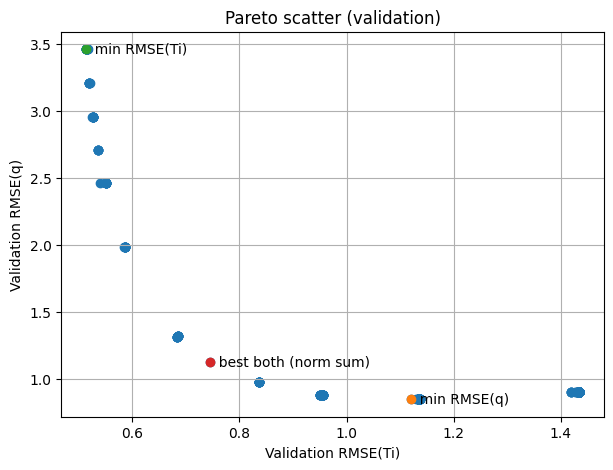

In [11]:
if RESULTS_CSV == "trained_params_home5_val_week_v3.csv":
    plt.figure(figsize=(7,5))
    plt.scatter(df_res["rmse_Ti_week"], df_res["rmse_q_week"])
    for lab, row in picked:
        plt.scatter([row["rmse_Ti_week"]], [row["rmse_q_week"]])
        plt.text(row["rmse_Ti_week"], row["rmse_q_week"], f"  {lab}", va="center")
    plt.grid(True)
    plt.xlabel("Validation RMSE(Ti)")
    plt.ylabel("Validation RMSE(q)")
    plt.title("Pareto scatter (validation)")
    plt.show()

elif RESULTS_CSV == "trained_params_val_home5.csv":
    plt.figure(figsize=(7,5))
    plt.scatter(df_res["rmse_dTi_val"], df_res["rmse_q_hp_val"])
    for lab, row in picked:
        plt.scatter([row["rmse_dTi_val"]], [row["rmse_q_hp_val"]])
        plt.text(row["rmse_dTi_val"], row["rmse_q_hp_val"], f"  {lab}", va="center")
    plt.grid(True)
    plt.xlabel("Validation RMSE(Ti)")
    plt.ylabel("Validation RMSE(q)")
    plt.title("Pareto scatter (validation)")
    plt.show()


In [8]:
# --- choose your validation week ---
WEEK_START = pd.to_datetime("2023-01-01 00:00:00")
WEEK_END   = WEEK_START + pd.Timedelta(days=7) - pd.Timedelta(minutes=30)

df_detached = pd.read_parquet(DETACHED_PARQUET)

# infer ID_USE if you didn't set it
    # If your results file stored the home, use it. Otherwise pick a reasonable default.
    # Most of your runs used "unique_ids[5]" — but we can't infer that from CSV alone.
    # So: pick the first Property_ID present.
unique_ids = df_detached["Property_ID"].unique()
ID_USE = unique_ids[HOME_INDEX]

df_home = df_detached[df_detached["Property_ID"] == ID_USE].copy()

# ensure timestamp index
if "Timestamp" in df_home.columns:
    df_home["Timestamp"] = pd.to_datetime(df_home["Timestamp"])
    df_home = df_home.set_index("Timestamp")
df_home = df_home.sort_index()

# engineer columns used by your model
df_home["Heat_Pump_Energy_Output_Diff"] = df_home["Heat_Pump_Energy_Output"].diff()
df_home["Internal_Temperature_Diff"] = df_home["Internal_Air_Temperature"].diff()
df_home["Internal_Ambient_Temperature_Diff"] = df_home["External_Air_Temperature"] - df_home["Internal_Air_Temperature"]

# light cleaning: interpolate short gaps on numeric cols, then drop remaining NaNs
num_cols = df_home.select_dtypes(include=["number"]).columns
df_home[num_cols] = df_home[num_cols].interpolate(method="time", limit=4, limit_direction="both")
df_home = df_home.dropna(subset=[
    "Internal_Air_Temperature",
    "External_Air_Temperature",
    "Internal_Ambient_Temperature_Diff",
    "Internal_Temperature_Diff",
    "SolarRadiation",
    "Heat_Pump_Energy_Output_Diff"
])

# week slice
df_week = df_home.loc[WEEK_START:WEEK_END].copy()
if len(df_week) < 10:
    raise RuntimeError(f"Not enough points in df_week: {len(df_week)}. Check WEEK_START/WEEK_END or missing data.")

# exact q streams for same window (30-min)
df_q_exact_all = pd.read_parquet(Q_STREAMS_PARQUET)
df_q_week = read_q_exact_30min(df_q_exact_all, ID_USE, WEEK_START, WEEK_END)

if "Q_spc_exact" not in df_q_week.columns:
    raise RuntimeError("Q_spc_exact not available in q_streams parquet for this home/window.")

# align q_real to df_week timeline
df_q_week_aligned = df_q_week.reindex(df_week.index)
if df_q_week_aligned["Q_spc_exact"].isna().any():
    # if small missing due to slight index mismatch, you can interpolate; otherwise error out
    miss = int(df_q_week_aligned["Q_spc_exact"].isna().sum())
    raise RuntimeError(f"{miss} missing Q_spc_exact points after alignment. Indices may not match exactly.")

print("df_week points:", len(df_week), "| df_q_week points:", len(df_q_week), "| aligned:", len(df_q_week_aligned))


df_week points: 336 | df_q_week points: 336 | aligned: 336


In [9]:
def simulate_week(params_row: pd.Series, df_week: pd.DataFrame, df_q_week_aligned: pd.DataFrame, delta_t_hours=0.5):
    """
    Returns:
      - q_real, q_hat_sim
      - Ti_sim_free: free-run (no daily reset)
      - Ti_sim_reinit: reset to measured Ti at midnight
    """
    C   = float(params_row["C"])
    R_a = float(params_row["R_a"])
    w_s = float(params_row["w_s"])
    w   = float(params_row["w"])

    L = len(df_week) - 1
    if L <= 0:
        raise RuntimeError("Week slice too short.")

    # exogenous vectors (length L)
    delta_T_a = df_week["Internal_Ambient_Temperature_Diff"].iloc[:-1].to_numpy(dtype=float)
    q_solar   = df_week["SolarRadiation"].iloc[:-1].to_numpy(dtype=float)

    # measured delta_T_i (length L), consistent with your training convention
    delta_T_i = (df_week["Internal_Air_Temperature"].diff().iloc[1:].to_numpy(dtype=float) / delta_t_hours)

    # exact "real" q for plotting (length L)
    q_real = df_q_week_aligned["Q_spc_exact"].iloc[:-1].to_numpy(dtype=float)

    # implied q_hat_sim (length L)
    q_hat_sim = (delta_T_i * C - (delta_T_a / R_a) * delta_t_hours - w_s * q_solar - w * delta_t_hours)

    # fallback q_opt
    q_opt = q_real.copy()

    # simulate Ti
    time_idx_state = df_week.index[1:]  # length L
    Ti_meas_state  = df_week["Internal_Air_Temperature"].iloc[1:].to_numpy(dtype=float)

    delta_T_i_sim = ((delta_T_a / R_a) * delta_t_hours + q_opt + w_s * q_solar + w * delta_t_hours) / C

    Ti_sim_free   = np.zeros(L, dtype=float)
    Ti_sim_reinit = np.zeros(L, dtype=float)

    # init from first measured state in the week
    Ti_prev_free   = float(df_week["Internal_Air_Temperature"].iloc[0])
    Ti_prev_reinit = float(df_week["Internal_Air_Temperature"].iloc[0])

    for k, t in enumerate(time_idx_state):
        # ----- free-run update -----
        Ti_sim_free[k] = Ti_prev_free + delta_T_i_sim[k] * delta_t_hours
        Ti_prev_free = Ti_sim_free[k]

        # ----- re-init update -----
        # if midnight, reset BEFORE applying the state update for this step
        if (t.hour == 0) and (t.minute == 0) and (t in df_week.index):
            Ti_prev_reinit = float(df_week.loc[t, "Internal_Air_Temperature"])

        Ti_sim_reinit[k] = Ti_prev_reinit + delta_T_i_sim[k] * delta_t_hours
        Ti_prev_reinit = Ti_sim_reinit[k]

    # RMSEs
    rmse_q_week  = float(np.sqrt(np.mean((q_hat_sim - q_real)**2)))
    rmse_T_free  = float(np.sqrt(np.mean((Ti_sim_free   - Ti_meas_state)**2)))
    rmse_T_reinit= float(np.sqrt(np.mean((Ti_sim_reinit - Ti_meas_state)**2)))

    return {
        "L": L,
        "time_q": df_week.index[:-1],
        "time_state": time_idx_state,
        "q_real": q_real,
        "q_hat_sim": q_hat_sim,
        "Ti_meas": Ti_meas_state,
        "Ti_sim_free": Ti_sim_free,
        "Ti_sim_reinit": Ti_sim_reinit,
        "rmse_q_week": rmse_q_week,
        "rmse_T_free": rmse_T_free,
        "rmse_T_reinit": rmse_T_reinit,
    }


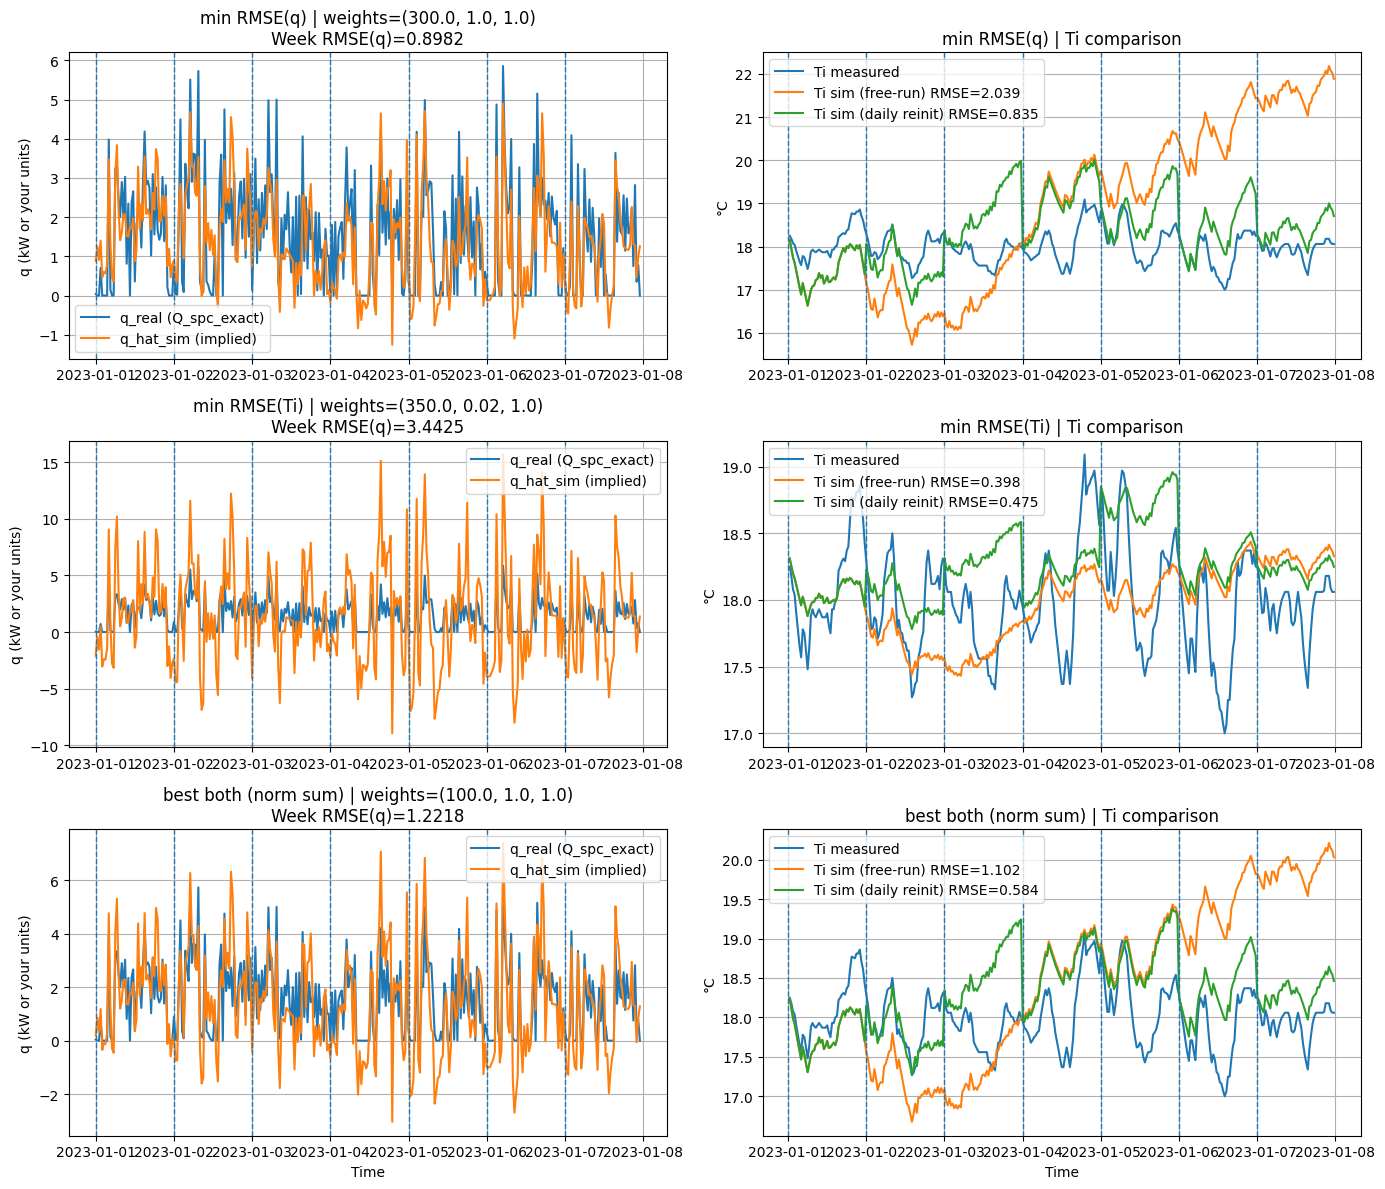

In [13]:
DELTA_T_HOURS = 0.5

fig, axes = plt.subplots(len(picked), 2, figsize=(14, 4 * len(picked)), sharex=False)
if len(picked) == 1:
    axes = np.array([axes])

# midnight markers for the chosen week
midnights = pd.date_range(df_week.index.min().normalize(),
                          df_week.index.max().normalize(),
                          freq="D")
midnights = [t for t in midnights if (t >= df_week.index.min()) and (t <= df_week.index.max())]

for ridx, (label, row) in enumerate(picked):
    sim = simulate_week(row, df_week, df_q_week_aligned, delta_t_hours=DELTA_T_HOURS)

    # ---- left: q ----
    axq = axes[ridx, 0]
    axq.plot(sim["time_q"], sim["q_real"], label="q_real (Q_spc_exact)")
    axq.plot(sim["time_q"], sim["q_hat_sim"], label="q_hat_sim (implied)")
    for t in midnights:
        axq.axvline(t, linestyle="--", linewidth=1)
    axq.grid(True)
    axq.set_ylabel("q (kW or your units)")
    axq.set_title(
        f"{label} | weights=({row['phi_q']}, {row['phi_e']}, {row['phi_u']})\n"
        f"Week RMSE(q)={sim['rmse_q_week']:.4f}"
    )
    axq.legend()

    # ---- right: Ti ----
    axt = axes[ridx, 1]
    axt.plot(sim["time_state"], sim["Ti_meas"], label="Ti measured")
    axt.plot(sim["time_state"], sim["Ti_sim_free"], label=f"Ti sim (free-run) RMSE={sim['rmse_T_free']:.3f}")
    axt.plot(sim["time_state"], sim["Ti_sim_reinit"], label=f"Ti sim (daily reinit) RMSE={sim['rmse_T_reinit']:.3f}")
    for t in midnights:
        axt.axvline(t, linestyle="--", linewidth=1)
    axt.grid(True)
    axt.set_ylabel("°C")
    axt.set_title(f"{label} | Ti comparison")
    axt.legend()

for ax in axes[-1, :]:
    ax.set_xlabel("Time")

plt.tight_layout()
plt.show()

